# FoodHub Data Analysis

### Problem Statement

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company improve its business.

### Data Dictionary

* order_id: Unique ID of the order

* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant’s order confirmation and the delivery person’s pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person’s pick-up confirmation and drop-off information.

### Let us start by importing the required libraries

In [ ]:
# Write your code here to import necessary libraries for the project
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
# Mount Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Write your code here to read the data
data = pd.read_csv('/content/drive/MyDrive/Module1/Project01/foodhub_order.csv')

In [ ]:
# Write your code here to view the first 5 rows
data.head(5)

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


In [ ]:
# Making a list of all categorical variables

data['cuisine_type'].unique()

cat_cols =  ['Korean', 'Japanese', 'Mexican', 'American', 'Indian', 'Italian',
       'Mediterranean', 'Chinese', 'Middle Eastern', 'Thai', 'Southern',
       'French', 'Spanish', 'Vietnamese']

# Printing the count of unique categorical levels in each column
for cuisine_type in cat_cols:
    counts = data['cuisine_type'].value_counts()
print(counts)

cuisine_type
American          584
Japanese          470
Italian           298
Chinese           215
Mexican            77
Indian             73
Middle Eastern     49
Mediterranean      46
Thai               19
French             18
Southern           17
Korean             13
Spanish            12
Vietnamese          7
Name: count, dtype: int64


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [ ]:
print("There are", data.shape[0], 'rows and', data.shape[1], "columns.")

There are 1898 rows and 9 columns.


#### Observations:
There are 1898 rows and 9 columns.

### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


#### Observations:
dtypes: float64(1), int64(4), object(4)


### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [ ]:
# Considering 'Not given' in rating column as missing value
data['rating'].unique()

array(['Not given', '5', '3', '4'], dtype=object)

In [ ]:
# replacing values with nan
data['rating'] = data['rating'].replace(['Not given'],np.nan)

In [ ]:
# repalaced 'Not given' to nan
data['rating'].unique()

array([nan, '5', '3', '4'], dtype=object)

In [ ]:
# changing the data type to float
data['rating'] = data['rating'].astype(float)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1162 non-null   float64
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(2), int64(4), object(3)
memory usage: 133.6+ KB


#### Observations:
As shown above 'rating' column is now float64 datatype.

### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [ ]:
#Statistical summary of data
data.describe()

,order_id,customer_id,cost_of_the_order,rating,food_preparation_time,delivery_time
count,1.898000e+03,1898.000000,1898.000000,1162.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,4.344234,27.371970,24.161749
std,5.480497e+02,113698.139743,7.483812,0.741478,4.632481,4.972637
min,1.476547e+06,1311.000000,4.470000,3.000000,20.000000,15.000000
25%,1.477021e+06,77787.750000,12.080000,4.000000,23.000000,20.000000
50%,1.477496e+06,128600.000000,14.140000,5.000000,27.000000,25.000000
75%,1.477970e+06,270525.000000,22.297500,5.000000,31.000000,28.000000
max,1.478444e+06,405334.000000,35.410000,5.000000,35.000000,33.000000


#### Observations:
* Minimumn food preparation time 20.0 mins.
* Average food preparation time 27.3 mins.
* Maximum food preparation time 35.0 mins.


### **Question 5:** How many orders are not rated? [1 mark]

In [ ]:
# Orders not rated
df_orders_not_rated = data['rating'].isnull().sum()
print("No. of orders not rated:",df_orders_not_rated)

No. of orders not rated: 736


#### Observations:
736 orders were not rated by customers.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

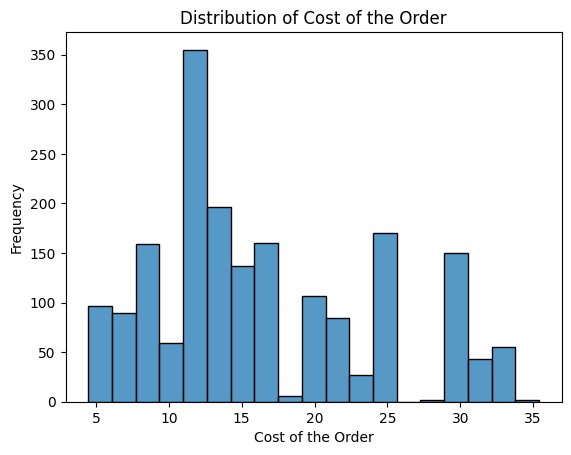

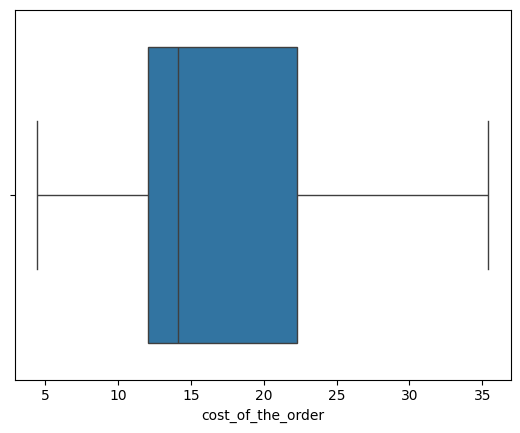

In [ ]:
sns.histplot(data=data,x='cost_of_the_order')
plt.xlabel('Cost of the Order')
plt.ylabel('Frequency')
plt.title('Distribution of Cost of the Order')
plt.show()
sns.boxplot(data=data,x='cost_of_the_order')
plt.show()

#### Observations:
* Most common Order Cost:
The highest bar is around 11-13 dollars with 350 orders. Also, high frequency around 8-10, 14-16 and 24-26 dollars.
* Low frequency zones:
Orders above 30 dollars have less number of orders.
* Skewed Distribution:
Distribution looks non symmentrical, customers are ordering in specific price brackets rather than contineous spread.


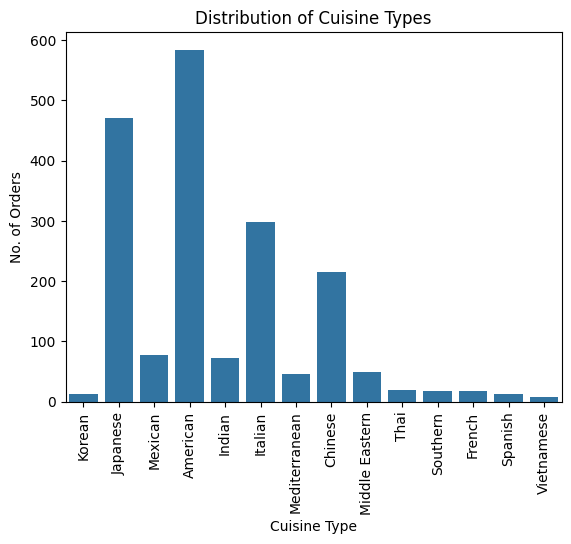

In [ ]:
sns.countplot(data=data,x='cuisine_type')
plt.xticks(rotation=90)
plt.xlabel('Cuisine Type')
plt.ylabel('No. of Orders')
plt.title('Distribution of Cuisine Types')
plt.show()

#### Observations:
* Most Popular Cuisine:
American cuisine got highest no. of orders around 580.
* Other Popular Choices:
Japanese cuisine is second with about 470 orders.
Italian and Chinese cuisines also have significant order volumes (~300 and ~220 respectively).
* Mid-Range Popularity:
Mexican, Indian, Mediterranean, and Middle Eastern cuisines sit somewhere in the middle (~50–80 orders).
* Least Popular Cuisines:
Vietnamese, Spanish, French, and Southern cuisines have very few orders (all under ~30).

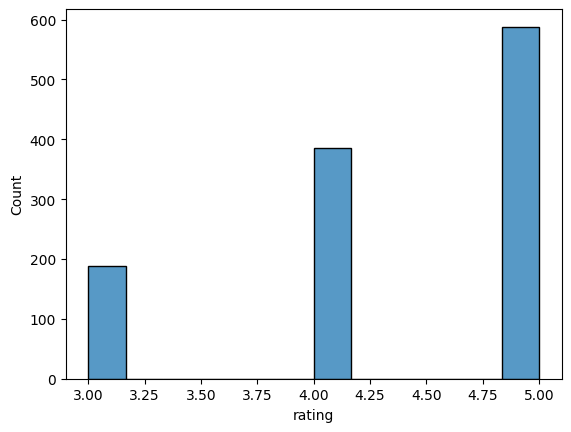

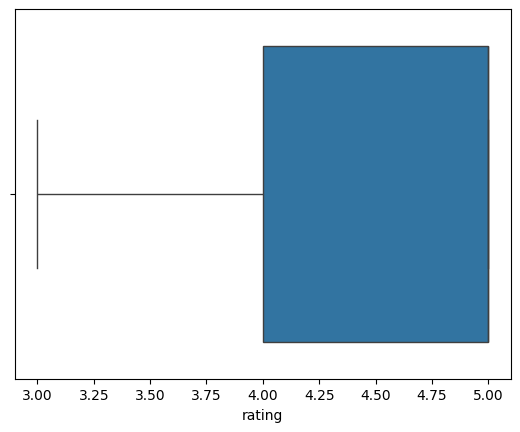

In [ ]:
sns.histplot(data=data,x='rating')
plt.show()
sns.boxplot(data=data,x='rating')
plt.show()

#### Observations:
* Most Common Rating:
A rating of 5 is the most frequent, with about 580 ratings.
* Moderately Common Rating:
A rating of 4 comes next, with about 380 ratings.
* Least Common Rating:
A rating of 3 is the least common, with around 190 ratings.


### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [ ]:
# Top 5 restaurants by no. of orders
data['restaurant_name'].value_counts().head(5)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


#### Observations:
Below are top 5 restaurants by orders:
  1. Shake Shack
  2. The Meatball Shop
  3. Blue Ribbon Sushi
  4. Blue Ribbon Fried Chicken
  5. Parm


### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [ ]:
# Most popular cuisine on weekends

df_restaurant_dayofweek = data.groupby(['cuisine_type'])['day_of_the_week'].value_counts()
df_restaurant_dayofweek.filter(like='Weekend').sort_values(ascending=False).head(1)

,,count
cuisine_type,day_of_the_week,
American,Weekend,415


#### Observations:
  Most Popular cuisine on weekends is "American" with 415 orders.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [ ]:
# Percentage of the orders cost more than 20 dollars
df_orders = (data['cost_of_the_order'] > 20).mean() * 100
print(f"{df_orders:.2f}% of the orders cost more than 20 dollars")

29.24% of the orders cost more than 20 dollars


#### Observations:
29.24% of the orders cost more than 20 dollars.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [ ]:
# Mean order delivery time
df_delivery_time = data['delivery_time'].mean()
print(f"The mean order delivery time is {df_delivery_time:.2f} minutes")

The mean order delivery time is 24.16 minutes


#### Observations:
The mean order delivery time is 24.16 minutes.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [ ]:
# top 3 customer ID which most orders placed
data['customer_id'].value_counts().head(3)

,count
customer_id,
52832,13
47440,10
83287,9


#### Observations:


### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


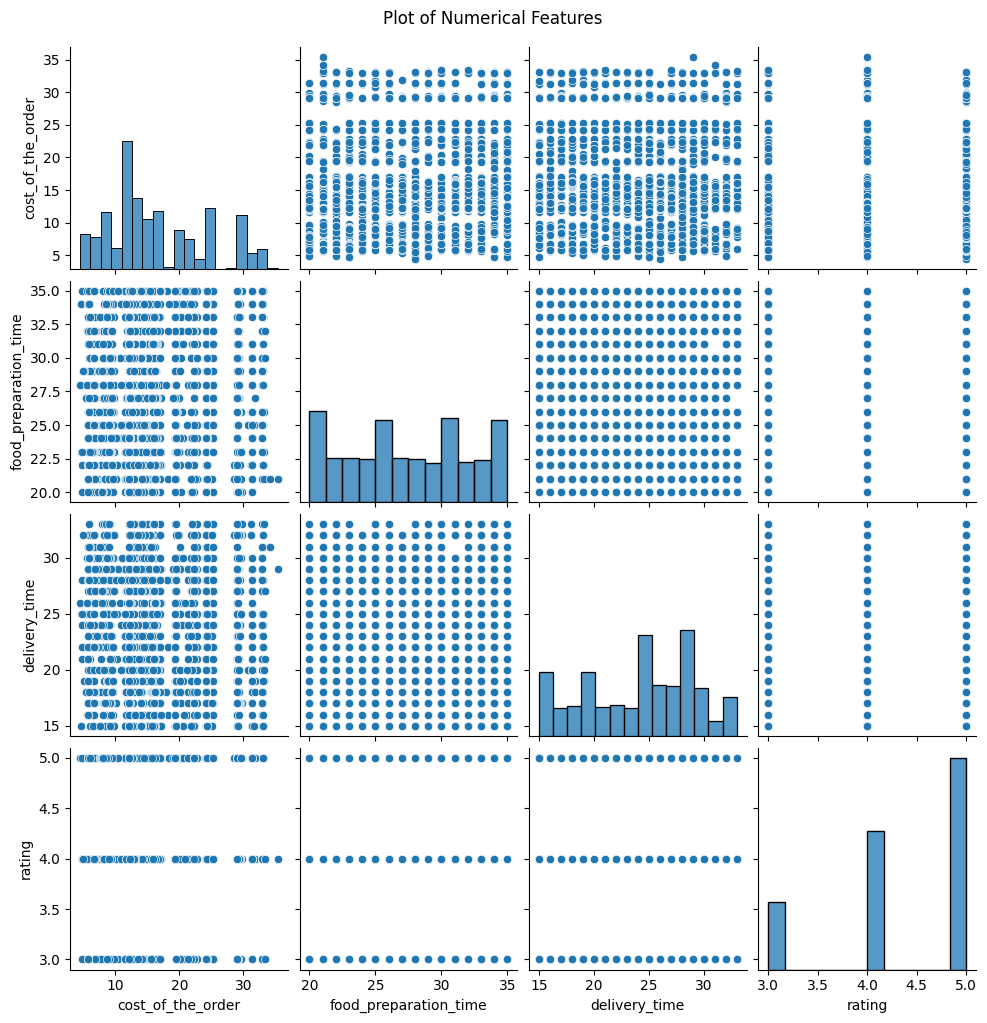

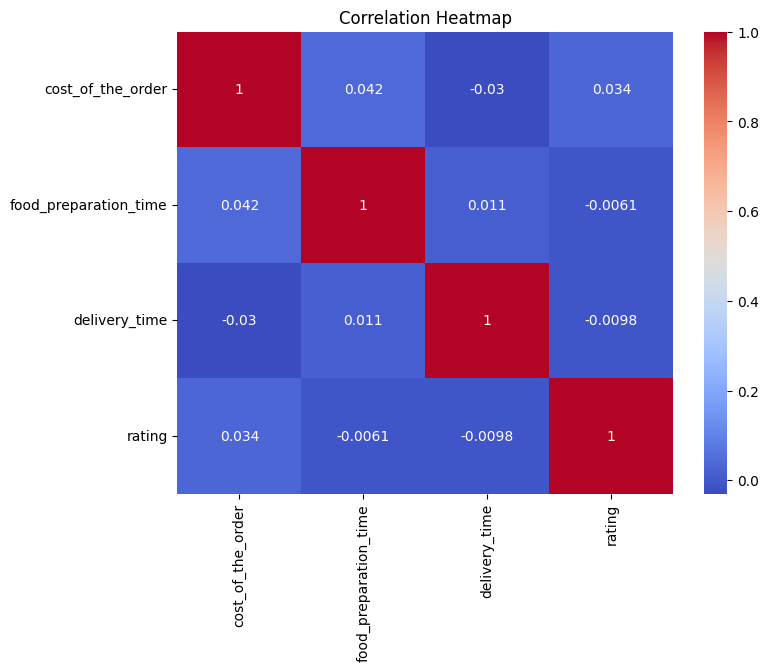

In [ ]:
## Numerical Analysis:

# Select important numerical columns
numerical_cols = ['cost_of_the_order', 'food_preparation_time', 'delivery_time', 'rating']

# Pairplot
sns.pairplot(data[numerical_cols])
plt.suptitle('Plot of Numerical Features', y=1.02)
plt.show()

# Correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(data[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

### Observations:
* Cost_of_the_order and Food_preparation_time are correlated, it might mean expensive orders take longer time to prepare.

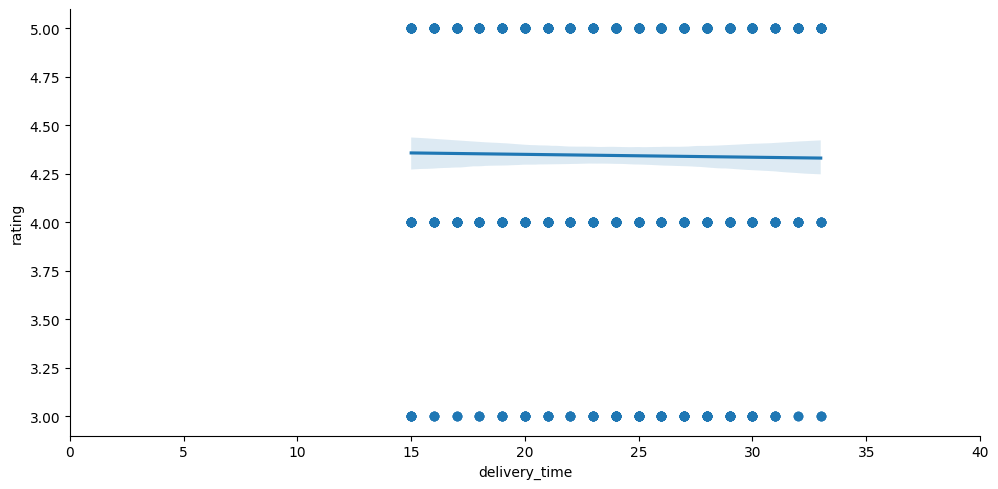

In [ ]:
## Numerical Analysis:

sns.lmplot(data=data,x='delivery_time',y='rating',height=5,aspect=2)
plt.xlim(0,40)
plt.show()

#### Observations:
* Delivery Time vs Rating:
  The line is almost flat, suggesting no strong  relationship between delivery time and rating.
* Ratings are discrete:
  A horizontal lines of dots at 3.0, 4.0, and 5.0 — showing that most users rate in whole numbers.
* No downward or upward trend:
  Since the regression line is flat, we can say that longer or shorter delivery times don’t significantly impact the rating — at least not linearly.



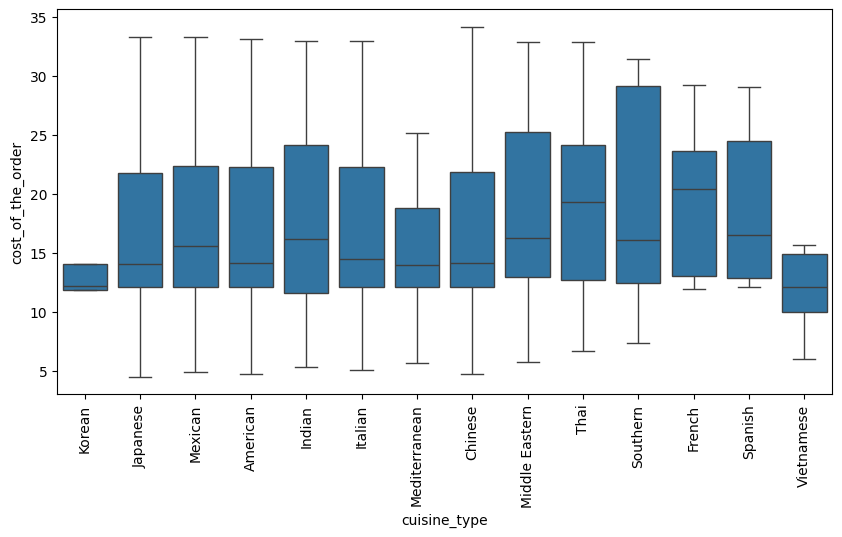

In [ ]:
## Categorical vs Numerical Analysis:

plt.figure(figsize=(10,5))
sns.boxplot(data=data,x='cuisine_type',y='cost_of_the_order',showfliers=False) # turning off outliers
plt.xticks(rotation=90)
plt.show()

#### Observations:
* Korean food has the least variability in cost — very tight box — costs are quite similar for Korean orders.
* Southern, Thai, and Middle Eastern cuisines have higher median costs and wider spread, meaning the prices vary a lot for these cuisines.
* Vietnamese and Mediterranean cuisines seem to have lower median costs compared to others.
* Some cuisines like Japanese, Mexican, American, Indian, Chinese, and Spanish have a large range of costs — they can be cheap or expensive.

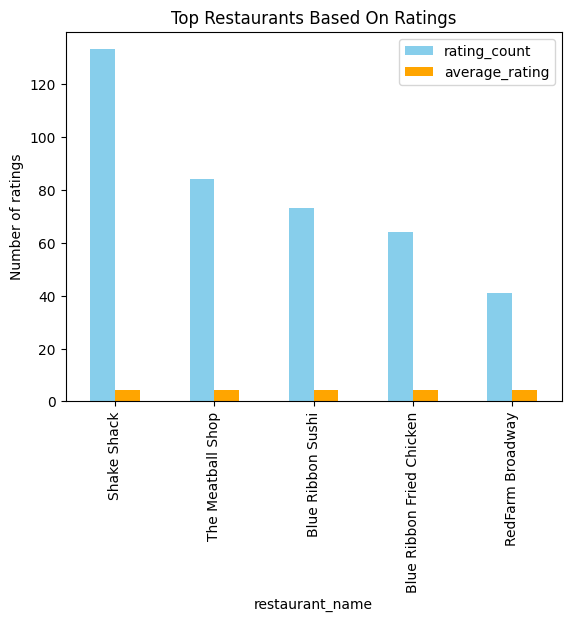

In [ ]:
# Top restaurant with highest ratings count
df_restaurant_ratings = data.groupby('restaurant_name').agg(
    rating_count=('rating', 'count'),
    average_rating=('rating', 'mean')
)
df_top_5_Restaurant =  df_restaurant_ratings.sort_values(by='rating_count', ascending=False).head(5)

df_top_5_Restaurant.plot(kind='bar', color=['skyblue', 'orange'])
plt.ylabel('Number of ratings')
plt.title('Top Restaurants Based On Ratings')
plt.xticks(rotation=90)
plt.show()


### Observations:
* Shake Shack has the highest number of ratings, over 130, indicating it’s very popular among customers.
* Other restaurants like The Meatball Shop, Blue Ribbon Sushi, and Blue Ribbon Fried Chicken follow in terms of number of ratings.
* The average rating across all these top restaurants is quite high and fairly consistent (the small orange bars), suggesting that not only are they popular, but also well-liked by customers.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [ ]:
# Group by restaurant name
df_restaurant_ratings = data.groupby('restaurant_name').agg(
    rating_count=('rating', 'count'),
    average_rating=('rating', 'mean')
)

# Filter restaurants
df_top_restaurants = df_restaurant_ratings[
    (df_restaurant_ratings['rating_count'] > 50) &
    (df_restaurant_ratings['average_rating'] > 4)]

print("Below are restaurants fulfilling the criteria to get promotional offer:\n")
print(df_top_restaurants)

Below are restaurants fulfilling the criteria to get promotional offer:

                           rating_count  average_rating
restaurant_name                                        
Blue Ribbon Fried Chicken            64        4.328125
Blue Ribbon Sushi                    73        4.219178
Shake Shack                         133        4.278195
The Meatball Shop                    84        4.511905


#### Observations:
* Shake Shack has the highest number of ratings 133, meaning it’s the most rated restaurant.
* The Meatball Shop has the highest average rating 4.51, meaning it is the best rated among these four despite having fewer total ratings than Shake Shack.
* Blue Ribbon Fried Chicken and Blue Ribbon Sushi also have strong average ratings above 4.2, showing good customer satisfaction.


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [ ]:
def calculate_revenue(cost):
    if cost > 20:
        return cost * 0.25
    elif cost > 5:
        return cost * 0.15
    else:
        return 0  # No revenue from orders with cost <= 5

# Apply the function to each row
data['company_revenue'] = data['cost_of_the_order'].apply(calculate_revenue)

# Calculate total net revenue
net_revenue = data['company_revenue'].sum()

print(f"Net Revenue generated by the company: ${net_revenue:.2f}")

Net Revenue generated by the company: $6166.30


#### Observations:
Net Revenue generated by the company: $6166.30

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [ ]:
# Find the number of orders taking more than 60 minutes
orders_over_60 = data[data['delivery_time'] > 60].shape[0]

# Find total number of orders
total_orders = data.shape[0]

# Calculate the percentage
percentage_over_60 = (orders_over_60 / total_orders) * 100

print(f"Percentage of orders taking more than 60 minutes: {percentage_over_60:.2f}%")

Percentage of orders taking more than 60 minutes: 0.00%


#### Observations:
There are no orders taking more than 60 minutes. The maximum delivery time recorded in the dataset is 33.0 minutes.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

Average Delivery Time On Weekday: 28.34 minutes
Average Delivery Time On Weekend: 22.47 minutes
-----------------------------------------------------------------


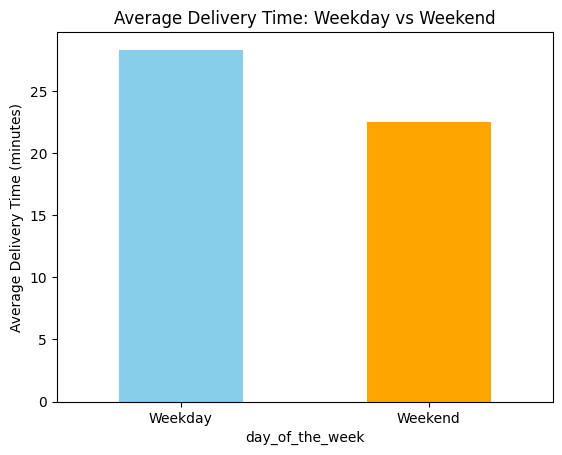

In [ ]:
# Mean delivery time on weekdays
Mean_weekday_delivery = data[data['day_of_the_week'].isin(['Weekday'])].groupby('day_of_the_week')['delivery_time'].mean()
print(f"Average Delivery Time On Weekday: {Mean_weekday_delivery.Weekday:.2f} minutes")


Mean_weekend_delivery = data[data['day_of_the_week'].isin(['Weekend'])].groupby('day_of_the_week')['delivery_time'].mean()
print(f"Average Delivery Time On Weekend: {Mean_weekend_delivery.Weekend:.2f} minutes")

# Combine the means
avg_times = pd.concat([Mean_weekday_delivery, Mean_weekend_delivery])

print("-" * 65)

# Plot
avg_times.plot(kind='bar', color=['skyblue', 'orange'])
plt.ylabel('Average Delivery Time (minutes)')
plt.title('Average Delivery Time: Weekday vs Weekend')
plt.xticks(rotation=0)
plt.show()

#### Observations:
* On weekdays, the average delivery time is 28.34 minutes
* On weekends, average delivery time decreases to 22.47 minutes, might be due to less traffic or more delivery partners employed.


### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
* There appears to be no significant relationship between delivery time and customer ratings.
* On weekdays, the average delivery time is 28.34 minutes
* Average delivery time drops to 22.47 minutes on weekends, possibly due to lighter traffic or more delivery partners being available.
* "Shake Shack" restaurant stands out with the highest number of ratings (133), making it the most reviewed restaurant.
* The most common customer rating is 5 stars, with approximately 580 occurrences.
* "American cuisine" is the most popular, receiving the highest number of orders at around 580.
* The average food preparation time across all orders is 27.3 minutes.
* Total of 735 orders were not rated by customers.


### Recommendations:

* Focus on Popular Cuisines:

  Since American cuisine is the most ordered, the company can partner with more American cuisine restaurants to meet customer demand. Promoting popular items through offers can boost orders even further.

* Leverage High-Rated Restaurants:

  Restaurants like Shake Shack that receive high numbers of positive ratings should be highlighted on the platform (like “Top Rated” or “Most Loved” tags). This can improve customer trust and attract more orders.

* Improve Lower-Rated Restaurants:
  
  Analyze customer feedback for restaurants with lower ratings. The company can suggest operational improvements (like faster service or better packaging) to these restaurants to help them enhance customer satisfaction.

* Weekend Promotions:

  Since delivery times are faster on weekends, the company can promote weekend deals or discounts to encourage more ordering during those days, ensuring quick delivery remains a competitive advantage.

* Optimize Delivery Logistics:
  
  Shorter weekend delivery times suggest that traffic or staffing adjustments matter. The company can replicate this model during peak weekday times by adjusting delivery partner allocation based on demand.

* Introduce Loyalty Programs for 5-Star Customers:

  Customers who consistently give high ratings could be offered reward points, discounts, or exclusive offers to encourage repeat business and positive word-of-mouth.

* Expand less popular Cuisine Types:

  While American cuisine is the most popular, other cuisines could be  promoted to diversify customer preferences. Introducing “Cuisine of the Week” campaigns or combo offers can help.

* Encourage Post-delivery Ratings
  
  Prompt users after order delivery with a simple, quick pop-up asking for a rating. Provide small discounts, rewards points or coupons.

